# BFSI Compliance Automation Pipeline

### BITS Pilani – Apex Project

**Student:** Ariyan Pal

**Roll Number:** 2025EB1100270

**Problem ID:** P5 – BFSI Compliance Automation Pipeline

---
# Table of Contents

1. Project Objective
2. Import Required Libraries
3. Load Dataset
4. Dataset Overview
5. Data Quality Assessment (Before)
6. Duplicate Removal
7. Date Standardization & Feature Engineering
8. Text Standardization
9. Missing Value Treatment
10. Feature Encoding & Scaling
11. Data Quality Assessment (After)
12. Exploratory Data Analysis
13. Dataset Export
14. Project Summary

## Project Objective

Financial institutions receive a large number of customer complaints through multiple channels. Before these records can be analysed, they must be cleaned, standardised and validated.

The objective of this notebook is to transform raw CFPB complaint records into a clean, analysis-ready dataset by performing data inspection, preprocessing, feature engineering and quality assessment.

This notebook follows the execution plan submitted during Week 2 of the Apex Project.

# Step 1 – Import Required Libraries

This project uses widely adopted Python libraries for data manipulation,
visualisation and preprocessing.

Only standard libraries required for this project are imported.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 – Load the Working Dataset

The filtered dataset generated using `filter_data.py` is loaded into memory for preprocessing.

A copy of the original dataset is preserved (`df_before`) so that data quality before and after preprocessing can be compared later in the notebook.

In [2]:
# Load the filtered dataset
df = pd.read_csv("cfpb_raw_2022_2024.csv", low_memory=False)

# Preserve a copy for before/after comparison
df_before = df.copy()

print("DATASET LOADED SUCCESSFULLY")
print("-" * 70)

print(f"Rows            : {df.shape[0]:,}")
print(f"Columns         : {df.shape[1]}")
print(
    f"Memory Usage    : "
    f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

print("\nCOLUMN NAMES")
print("-" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print("\nDataset loaded successfully.")

DATASET LOADED SUCCESSFULLY
----------------------------------------------------------------------
Rows            : 350,000
Columns         : 16
Memory Usage    : 446.50 MB

COLUMN NAMES
----------------------------------------------------------------------
01. Date received
02. Product
03. Sub-product
04. Issue
05. Sub-issue
06. Consumer complaint narrative
07. Company public response
08. Company
09. State
10. ZIP code
11. Tags
12. Submitted via
13. Date sent to company
14. Company response to consumer
15. Timely response?
16. Complaint ID

Dataset loaded successfully.


# Step 3 – Initial Dataset Overview

Before performing any preprocessing, the dataset is inspected to understand its
structure, data types, and overall quality.

This helps identify potential issues such as missing values, incorrect data
types, or duplicate records before cleaning begins.

In [3]:

print("FIRST FIVE RECORDS")
print("-" * 50)


display(df.head())

print("\n")

print("-" * 50)

print("DATASET INFORMATION")

print("-" * 50)


df.info()

print("\n")

print("-" * 50)
print("NUMERICAL SUMMARY")
print("-" * 50)

display(df.describe())

print("\n")

print("-" * 50)
print("CATEGORICAL SUMMARY")
print("-" * 50)

display(df.describe(include="object").T)

FIRST FIVE RECORDS
--------------------------------------------------


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2022-01-01,Student loan,Federal student loan servicing,Problem with a credit reporting company's investigation into an existing problem,Problem with personal statement of dispute,NaN,NaN,AES/PHEAA,CA,91203,NaN,Web,2022-01-01,Closed with explanation,Yes,5063851.0
1,2022-01-01,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Their investigation did not fix an error on your report,"For several months, i've relentlessly tried to get inaccuracies removed from my credit so that m...",NaN,"National Credit Systems,Inc.",GA,303XX,NaN,Web,2022-01-01,Closed with explanation,Yes,5061287.0
2,2022-01-01,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",PA,19129,NaN,Web,2022-01-01,Closed with explanation,Yes,5061551.0
3,2022-01-01,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",PA,17113,NaN,Web,2022-01-01,Closed with explanation,Yes,5061497.0
4,2022-01-01,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,TX,75454,NaN,Web,2022-01-01,Closed with non-monetary relief,Yes,5061636.0




--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350000 entries, 0 to 349999
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date received                 350000 non-null  object 
 1   Product                       350000 non-null  object 
 2   Sub-product                   349998 non-null  object 
 3   Issue                         350000 non-null  object 
 4   Sub-issue                     341089 non-null  object 
 5   Consumer complaint narrative  118819 non-null  object 
 6   Company public response       210578 non-null  object 
 7   Company                       350000 non-null  object 
 8   State                         349147 non-null  object 
 9   ZIP code                      350000 non-null  object 
 10  Tags                          19272 non-

,Complaint ID
count,3.500000e+05
mean,8.407838e+06
std,1.755270e+06
min,5.059835e+06
25%,6.945792e+06
50%,8.483324e+06
75%,9.921629e+06
max,2.357750e+07




--------------------------------------------------
CATEGORICAL SUMMARY
--------------------------------------------------


,count,unique,top,freq
Date received,350000,1109,2024-12-11,1007
Product,350000,14,Credit reporting or other personal consumer reports,201191
Sub-product,349998,57,Credit reporting,289775
Issue,350000,90,Incorrect information on your report,135647
Sub-issue,341089,208,Information belongs to someone else,87194
Consumer complaint narrative,118819,92852,In accordance with the Fair Credit Reporting act. The List of accounts below has violated my fed...,1388
Company public response,210578,10,Company has responded to the consumer and the CFPB and chooses not to provide a public response,204483
Company,350000,2195,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",95648
State,349147,59,FL,47536
ZIP code,350000,15614,XXXXX,2859


# Step 4 – Data Quality Assessment (Before Preprocessing)

Before applying any preprocessing techniques, the overall quality of the dataset
is evaluated.

The assessment focuses on:

- Dataset dimensions
- Duplicate records
- Missing values
- Data types
- Overall completeness

This serves as the baseline against which the cleaned dataset will later be compared.

In [4]:
print("-" * 45)
print("DATA QUALITY SUMMARY (BEFORE PREPROCESSING)")
print("-" * 45)

total_rows = len(df)
total_columns = len(df.columns)

duplicate_rows = df.duplicated().sum()
duplicate_complaint_ids = df["Complaint ID"].duplicated().sum()

total_cells = total_rows * total_columns
missing_cells = df.isnull().sum().sum()

completeness = (
    (total_cells - missing_cells)
    / total_cells
) * 100

quality_summary_before = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Duplicate Complaint IDs",
        "Total Missing Values",
        "Dataset Completeness (%)"
    ],
    "Value": [
        f"{total_rows:,}",
        total_columns,
        f"{duplicate_rows:,}",
        f"{duplicate_complaint_ids:,}",
        f"{missing_cells:,}",
        f"{completeness:.2f}%"
    ]
})

display(quality_summary_before)

---------------------------------------------
DATA QUALITY SUMMARY (BEFORE PREPROCESSING)
---------------------------------------------


,Metric,Value
0,Total Rows,"350,000"
1,Total Columns,16
2,Duplicate Rows,0
3,Duplicate Complaint IDs,0
4,Total Missing Values,"711,101"
5,Dataset Completeness (%),87.30%


In [5]:
missing_report_before = (
    pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Percentage (%)": (
            df.isnull().sum() / len(df) * 100
        ).round(2)
    })
)

missing_report_before = (
    missing_report_before
    .sort_values(
        by="Missing Values",
        ascending=False
    )
)

display(missing_report_before)

,Missing Values,Percentage (%)
Tags,330728,94.49
Consumer complaint narrative,231181,66.05
Company public response,139422,39.83
Sub-issue,8911,2.55
State,853,0.24
Company response to consumer,3,0.00
Sub-product,2,0.00
Date sent to company,1,0.00
Company,0,0.00
Date received,0,0.00


In [6]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Values": df.count().values
})

display(dtype_report)

,Column,Data Type,Non-Null Values
Date received,Date received,object,350000
Product,Product,object,350000
Sub-product,Sub-product,object,349998
Issue,Issue,object,350000
Sub-issue,Sub-issue,object,341089
Consumer complaint narrative,Consumer complaint narrative,object,118819
Company public response,Company public response,object,210578
Company,Company,object,350000
State,State,object,349147
ZIP code,ZIP code,object,350000


In [7]:
print("-" * 25)
print("INITIAL OBSERVATIONS")
print("-" * 25)

print(f"Dataset contains {total_rows:,} complaint records.")
print(f"Dataset has {total_columns} attributes.")

print(f"\nDuplicate rows found : {duplicate_rows:,}")
print(f"Duplicate Complaint IDs : {duplicate_complaint_ids:,}")

print(f"\nTotal missing values : {missing_cells:,}")
print(f"Dataset completeness : {completeness:.2f}%")

-------------------------
INITIAL OBSERVATIONS
-------------------------
Dataset contains 350,000 complaint records.
Dataset has 16 attributes.

Duplicate rows found : 0
Duplicate Complaint IDs : 0

Total missing values : 711,101
Dataset completeness : 87.30%


# Step 5 – Duplicate Removal

Duplicate records can introduce bias into complaint counts and analytical results.

Two types of duplicates are examined:

1. Completely identical rows.
2. Duplicate **Complaint ID** values, where each Complaint ID should uniquely identify a complaint.

Only the first occurrence of each Complaint ID is retained.

In [8]:
rows_before = len(df)

duplicate_rows_before = df.duplicated().sum()

duplicate_ids_before = df["Complaint ID"].duplicated().sum()

print("-" * 44)
print("DUPLICATE ANALYSIS (BEFORE CLEANING)")
print("-" * 45)

print(f"Rows in dataset                : {rows_before:,}")
print(f"Completely duplicate rows      : {duplicate_rows_before:,}")
print(f"Duplicate Complaint IDs        : {duplicate_ids_before:,}")

--------------------------------------------
DUPLICATE ANALYSIS (BEFORE CLEANING)
---------------------------------------------
Rows in dataset                : 350,000
Completely duplicate rows      : 0
Duplicate Complaint IDs        : 0


In [9]:
df = df.drop_duplicates(
    subset="Complaint ID",
    keep="first"
).reset_index(drop=True)

In [10]:
rows_after = len(df)

duplicate_rows_after = df.duplicated().sum()

duplicate_ids_after = df["Complaint ID"].duplicated().sum()

removed_rows = rows_before - rows_after

print("-" * 45)
print("DUPLICATE ANALYSIS (AFTER CLEANING)")
print("-" * 45)

print(f"Rows remaining                 : {rows_after:,}")
print(f"Rows removed                   : {removed_rows:,}")
print(f"Duplicate rows remaining       : {duplicate_rows_after:,}")
print(f"Duplicate Complaint IDs        : {duplicate_ids_after:,}")

---------------------------------------------
DUPLICATE ANALYSIS (AFTER CLEANING)
---------------------------------------------
Rows remaining                 : 350,000
Rows removed                   : 0
Duplicate rows remaining       : 0
Duplicate Complaint IDs        : 0


In [11]:
duplicate_summary = pd.DataFrame({
    "Metric": [
        "Rows Before Cleaning",
        "Rows After Cleaning",
        "Rows Removed",
        "Duplicate Rows Remaining",
        "Duplicate Complaint IDs Remaining"
    ],
    "Value": [
        f"{rows_before:,}",
        f"{rows_after:,}",
        f"{removed_rows:,}",
        f"{duplicate_rows_after:,}",
        f"{duplicate_ids_after:,}"
    ]
})

display(duplicate_summary)

,Metric,Value
0,Rows Before Cleaning,"350,000"
1,Rows After Cleaning,"350,000"
2,Rows Removed,0
3,Duplicate Rows Remaining,0
4,Duplicate Complaint IDs Remaining,0


# Step 6 – Date Standardization and Feature Engineering

The complaint dataset contains two important date fields:

- **Date received** – when the complaint was submitted.
- **Date sent to company** – when the complaint was forwarded to the company.

Both columns are converted to a standard datetime format to ensure consistency.

A new feature, **resolution_days**, is then created to measure the number of days between receiving the complaint and forwarding it to the company.

Any negative values (which indicate inconsistent dates) are treated as invalid and replaced with missing values.

In [12]:
print("." * 25)
print("DATE STANDARDIZATION")
print("." * 25)

date_columns = [
    "Date received",
    "Date sent to company"
]

for column in date_columns:

    invalid_before = df[column].isna().sum()

    df[column] = (
        pd.to_datetime(
            df[column],
            errors="coerce",
            utc=True
        )
        .dt.tz_localize(None)
    )

    invalid_after = df[column].isna().sum()

    newly_invalid = invalid_after - invalid_before

    print(f"\n{column}")
    print(f"Missing / Invalid Dates : {invalid_after:,}")

    if newly_invalid > 0:
        print(f"New invalid dates detected : {newly_invalid:,}")

.........................
DATE STANDARDIZATION
.........................

Date received
Missing / Invalid Dates : 31,250
New invalid dates detected : 31,250

Date sent to company
Missing / Invalid Dates : 31,250
New invalid dates detected : 31,249


In [13]:
print("\n" + "." * 35)
print("CREATING FEATURE : resolution_days")
print("." * 35)

df["resolution_days"] = (
    df["Date sent to company"] -
    df["Date received"]
).dt.days

print("Feature created successfully.")


...................................
CREATING FEATURE : resolution_days
...................................
Feature created successfully.


In [14]:
negative_days = (df["resolution_days"] < 0).sum()

print(f"\nNegative resolution days found : {negative_days:,}")

if negative_days > 0:

    df.loc[
        df["resolution_days"] < 0,
        "resolution_days"
    ] = np.nan

    print("Negative values replaced with NaN.")

else:

    print("No negative values found.")


Negative resolution days found : 0
No negative values found.


In [15]:
print("\n" + "." * 25)
print("RESOLUTION DAYS SUMMARY")
print("." * 25)

display(
    df["resolution_days"]
    .describe()
    .to_frame()
)


.........................
RESOLUTION DAYS SUMMARY
.........................


,resolution_days
count,318750.000000
mean,0.364866
std,3.626441
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,409.000000


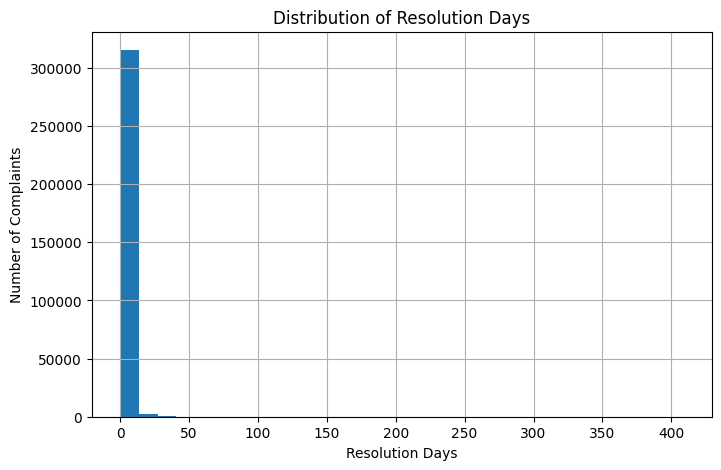

In [16]:
plt.figure(figsize=(8,5))

df["resolution_days"].hist(
    bins=30
)

plt.title("Distribution of Resolution Days")
plt.xlabel("Resolution Days")
plt.ylabel("Number of Complaints")

plt.show()

# Step 7 – Standardization of Text Fields

Several categorical columns may contain inconsistencies such as:

- Leading or trailing spaces
- Multiple consecutive spaces
- Inconsistent capitalization

These inconsistencies can result in duplicate categories during analysis (for example, "Credit card", " credit card", and "CREDIT CARD" being treated as different values).

To improve consistency, the selected text columns are standardised by:

- Removing leading and trailing whitespace.
- Replacing multiple spaces with a single space.
- Converting text to Title Case.

Missing values are preserved and handled separately in the next step.

In [17]:
print("." * 30)
print("TEXT STANDARDIZATION")
print("." * 30)

text_columns = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "Company public response",
    "Company response to consumer",
    "Submitted via",
    "State",
    "Tags"
]

print("Columns selected for standardization:\n")

for column in text_columns:
    print(f"• {column}")

..............................
TEXT STANDARDIZATION
..............................
Columns selected for standardization:

• Product
• Sub-product
• Issue
• Sub-issue
• Company
• Company public response
• Company response to consumer
• Submitted via
• State
• Tags


In [18]:
changes = {}

for column in text_columns:

    before = df[column].copy()

    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

    changed = (
        before.fillna("Missing")
        !=
        df[column].fillna("Missing")
    ).sum()

    changes[column] = changed

In [19]:
standardization_report = pd.DataFrame({
    "Column": list(changes.keys()),
    "Values Modified": list(changes.values())
})

display(standardization_report)


,Column,Values Modified
0,Product,345034
1,Sub-product,347527
2,Issue,349681
3,Sub-issue,340975
4,Company,243260
5,Company public response,210578
6,Company response to consumer,349997
7,Submitted via,1242
8,State,349147
9,Tags,0


In [20]:
total_changes = sum(changes.values())

print("-" * 255)
print("STANDARDIZATION SUMMARY")
print("-" * 25)

print(f"Columns processed : {len(text_columns)}")
print(f"Values modified   : {total_changes:,}")

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
STANDARDIZATION SUMMARY
-------------------------
Columns processed : 10
Values modified   : 2,537,441


# Step 8 – Missing Value Treatment

Missing values are common in real-world complaint datasets. Different columns
represent different types of information, so a single strategy cannot be applied
to every column.

The following treatment strategies are used:

| Column | Strategy | Reason |
|--------|----------|--------|
| State | Replace with **"Unknown"** | Complaint location is unavailable but the record is still useful. |
| ZIP code | Replace with **"Unknown"** | Prevents losing complaint records due to missing postal codes. |
| Company response to consumer | Replace with **"No Response"** | Clearly distinguishes missing responses from actual response categories. |
| Timely response? | Replace with **"Unknown"** | Indicates that timeliness information is unavailable. |
| Consumer complaint narrative | Not imputed | Instead, a binary feature (`has_narrative`) is created. |

This approach preserves the maximum number of complaint records while maintaining
the meaning of each attribute.

In [21]:
print("." * 35)
print("MISSING VALUES BEFORE TREATMENT")
print("." * 35)

missing_before = df.isnull().sum()

missing_before = (
    missing_before[missing_before > 0]
    .sort_values(ascending=False)
)

display(
    pd.DataFrame({
        "Missing Values": missing_before,
        "Percentage (%)":
        (
            missing_before / len(df) * 100
        ).round(2)
    })
)

...................................
MISSING VALUES BEFORE TREATMENT
...................................


,Missing Values,Percentage (%)
Tags,330728,94.49
Consumer complaint narrative,231181,66.05
Company public response,139422,39.83
Date received,31250,8.93
resolution_days,31250,8.93
Date sent to company,31250,8.93
Sub-issue,8911,2.55
State,853,0.24
Company response to consumer,3,0.00
Sub-product,2,0.00


In [22]:
# Preserve missing narrative information separately
df["has_narrative"] = (
    df["Consumer complaint narrative"]
    .notna()
    .astype(int)
)

# Fill selected categorical columns
fill_values = {
    "State": "Unknown",
    "ZIP code": "Unknown",
    "Company response to consumer": "No Response",
    "Timely response?": "Unknown"
}

df.fillna(value=fill_values, inplace=True)

In [23]:
print("." * 75)
print("MISSING VALUES AFTER TREATMENT")
print("." * 75)

missing_after = df.isnull().sum()

missing_after = (
    missing_after[missing_after > 0]
    .sort_values(ascending=False)
)

if missing_after.empty:

    print("No remaining missing values in treated columns.")

else:

    display(
        pd.DataFrame({
            "Missing Values": missing_after,
            "Percentage (%)":
            (
                missing_after / len(df) * 100
            ).round(2)
        })
    )

...........................................................................
MISSING VALUES AFTER TREATMENT
...........................................................................


,Missing Values,Percentage (%)
Tags,330728,94.49
Consumer complaint narrative,231181,66.05
Company public response,139422,39.83
Date received,31250,8.93
Date sent to company,31250,8.93
resolution_days,31250,8.93
Sub-issue,8911,2.55
Sub-product,2,0.00


In [24]:
treatment_summary = pd.DataFrame({
    "Column": [
        "State",
        "ZIP code",
        "Company response to consumer",
        "Timely response?",
        "Consumer complaint narrative"
    ],
    "Treatment": [
        "Filled with 'Unknown'",
        "Filled with 'Unknown'",
        "Filled with 'No Response'",
        "Filled with 'Unknown'",
        "Binary feature created (has_narrative)"
    ]
})

display(treatment_summary)

,Column,Treatment
0,State,Filled with 'Unknown'
1,ZIP code,Filled with 'Unknown'
2,Company response to consumer,Filled with 'No Response'
3,Timely response?,Filled with 'Unknown'
4,Consumer complaint narrative,Binary feature created (has_narrative)


In [25]:
print("-" * 75)
print("NARRATIVE FEATURE SUMMARY")
print("-" * 75)

display(
    df["has_narrative"]
    .value_counts()
    .rename_axis("Has Narrative")
    .to_frame("Number of Complaints")
)

---------------------------------------------------------------------------
NARRATIVE FEATURE SUMMARY
---------------------------------------------------------------------------


,Number of Complaints
Has Narrative,
0,231181
1,118819


# Step 9 – Feature Encoding and Transformation

Some machine learning and analytical techniques require numerical
representations of categorical variables.

Instead of replacing the original columns, encoded versions are created.
This preserves the original information while providing numerical
representations for future analysis.

The following transformations are performed:

- **Timely response?** → Numeric encoding
- **Product** → Category codes
- **resolution_days** → Min-Max Scaling

In [26]:
timely_map = {'Yes': 1, 'No': 0, 'Unknown': -1}
df['Timely response?_encoded'] = df['Timely response?'].map(timely_map)
df['Product_encoded'] = pd.Categorical(df['Product']).codes
print("Categorical encoding completed.")

Categorical encoding completed.


In [27]:
print("." * 720)
print("ENCODING : Product")
print("." * 20)

df["product_encoded"] = (
    pd.Categorical(df["Product"])
    .codes
)

print(
    f"Unique Product Categories : "
    f"{df['Product'].nunique()}"
)

................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
ENCODING : Product
....................
Unique Product Categories : 14


In [28]:
print("-" * 25)
print("MIN-MAX SCALING")
print("-" * 25)

median_resolution = (
    df["resolution_days"]
    .median()
)

scaled_input = (
    df["resolution_days"]
    .fillna(median_resolution)
)

scaler = MinMaxScaler()

df["resolution_days_scaled"] = (
    scaler.fit_transform(
        scaled_input.to_frame()
    )
)

print("Scaling completed successfully.")

-------------------------
MIN-MAX SCALING
-------------------------
Scaling completed successfully.


In [29]:
encoding_summary = pd.DataFrame({
    "Feature": [
        "Timely Response",
        "Product",
        "Resolution Days"
    ],
    "Transformation": [
        "Manual Mapping",
        "Category Encoding",
        "Min-Max Scaling"
    ],
    "Output Column": [
        "timely_response_encoded",
        "product_encoded",
        "resolution_days_scaled"
    ]
})

display(encoding_summary)

,Feature,Transformation,Output Column
0,Timely Response,Manual Mapping,timely_response_encoded
1,Product,Category Encoding,product_encoded
2,Resolution Days,Min-Max Scaling,resolution_days_scaled


# Step 10 – Data Quality Assessment (After Preprocessing)

After completing preprocessing, the dataset is evaluated again to measure the
impact of the cleaning operations.

The following quality indicators are compared with the original dataset:

- Dataset dimensions
- Duplicate records
- Missing values
- Dataset completeness
- New engineered features

This comparison helps verify that preprocessing has improved the overall quality
of the dataset while preserving useful complaint information.

In [30]:
print("/" * 35)
print("DATA QUALITY SUMMARY (AFTER PREPROCESSING)")
print("/" * 35)

rows_after_cleaning = len(df)
columns_after_cleaning = len(df.columns)

duplicate_rows_after = df.duplicated().sum()
duplicate_ids_after = df["Complaint ID"].duplicated().sum()

missing_after = df.isnull().sum().sum()

total_cells_after = (
    rows_after_cleaning *
    columns_after_cleaning
)

completeness_after = (
    (total_cells_after - missing_after)
    / total_cells_after
) * 100

///////////////////////////////////
DATA QUALITY SUMMARY (AFTER PREPROCESSING)
///////////////////////////////////


In [31]:
quality_summary_after = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Duplicate Complaint IDs",
        "Total Missing Values",
        "Dataset Completeness (%)"
    ],
    "Value": [
        f"{rows_after_cleaning:,}",
        columns_after_cleaning,
        f"{duplicate_rows_after:,}",
        f"{duplicate_ids_after:,}",
        f"{missing_after:,}",
        f"{completeness_after:.2f}%"
    ]
})

display(quality_summary_after)

,Metric,Value
0,Total Rows,"350,000"
1,Total Columns,22
2,Duplicate Rows,0
3,Duplicate Complaint IDs,0
4,Total Missing Values,"803,994"
5,Dataset Completeness (%),89.56%


In [32]:
comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Rows",
        "Duplicate Complaint IDs",
        "Missing Values",
        "Completeness (%)"
    ],
    "Before": [
        total_rows,
        total_columns,
        duplicate_rows,
        duplicate_complaint_ids,
        missing_cells,
        round(completeness, 2)
    ],
    "After": [
        rows_after_cleaning,
        columns_after_cleaning,
        duplicate_rows_after,
        duplicate_ids_after,
        missing_after,
        round(completeness_after, 2)
    ]
})

display(comparison)

,Metric,Before,After
0,Rows,350000.0,350000.00
1,Columns,16.0,22.00
2,Duplicate Rows,0.0,0.00
3,Duplicate Complaint IDs,0.0,0.00
4,Missing Values,711101.0,803994.00
5,Completeness (%),87.3,89.56


In [33]:
new_features = [
    "resolution_days",
    "resolution_days_original",
    "resolution_days_scaled",
    "has_narrative",
    "timely_response_encoded",
    "product_encoded"
]

feature_report = pd.DataFrame({
    "New Feature": new_features,
    "Description": [
        "Complaint processing duration",
        "Original resolution days",
        "Scaled resolution days",
        "Narrative availability flag",
        "Encoded timely response",
        "Encoded product category"
    ]
})

display(feature_report)

,New Feature,Description
0,resolution_days,Complaint processing duration
1,resolution_days_original,Original resolution days
2,resolution_days_scaled,Scaled resolution days
3,has_narrative,Narrative availability flag
4,timely_response_encoded,Encoded timely response
5,product_encoded,Encoded product category


In [34]:
print("PREPROCESSING SUMMARY")


print(f"Initial Records              : {total_rows:,}")
print(f"Final Records                : {rows_after_cleaning:,}")

print(f"\nDuplicate Rows Removed       : {duplicate_rows - duplicate_rows_after:,}")
print(f"Duplicate Complaint IDs      : {duplicate_complaint_ids - duplicate_ids_after:,}")

print(f"\nMissing Values Before        : {missing_cells:,}")
print(f"Missing Values After         : {missing_after:,}")

print(f"\nCompleteness Before          : {completeness:.2f}%")
print(f"Completeness After           : {completeness_after:.2f}%")

print(f"\nNew Features Created         : {len(new_features)}")

PREPROCESSING SUMMARY
Initial Records              : 350,000
Final Records                : 350,000

Duplicate Rows Removed       : 0
Duplicate Complaint IDs      : 0

Missing Values Before        : 711,101
Missing Values After         : 803,994

Completeness Before          : 87.30%
Completeness After           : 89.56%

New Features Created         : 6


# Step 11 – Complaint Volume by Product

Understanding which financial products receive the highest number of complaints
helps identify areas requiring greater regulatory attention.

This analysis ranks products according to complaint frequency.

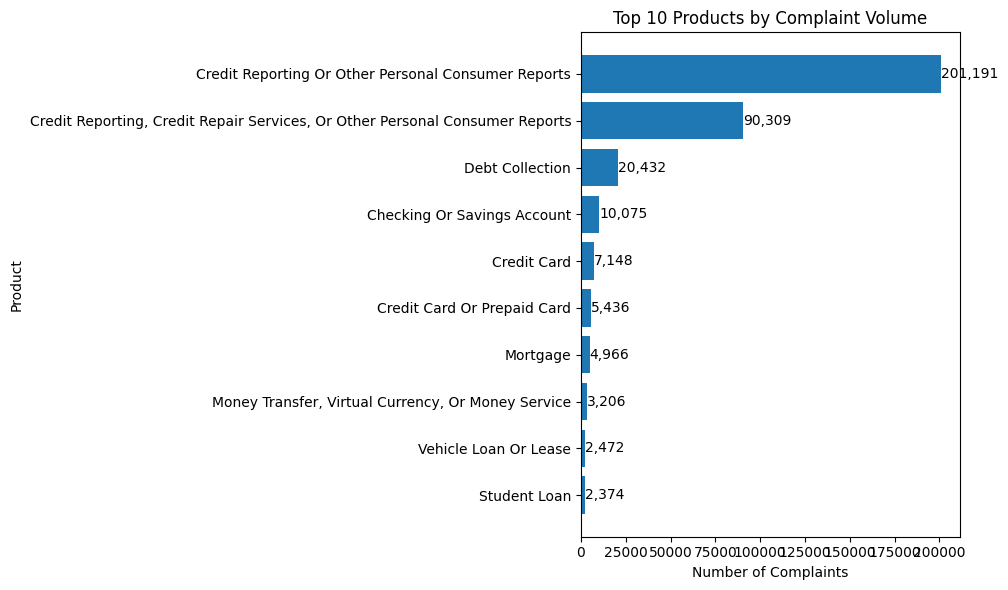

In [35]:
product_counts = (
    df["Product"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    product_counts.index,
    product_counts.values
)

plt.title("Top 10 Products by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")

for bar in bars:

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "charts/chart_product_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 12 – Complaint Distribution by State

Complaint distribution across states provides insight into the geographical
spread of consumer issues.

Only the top fifteen states are displayed for readability.

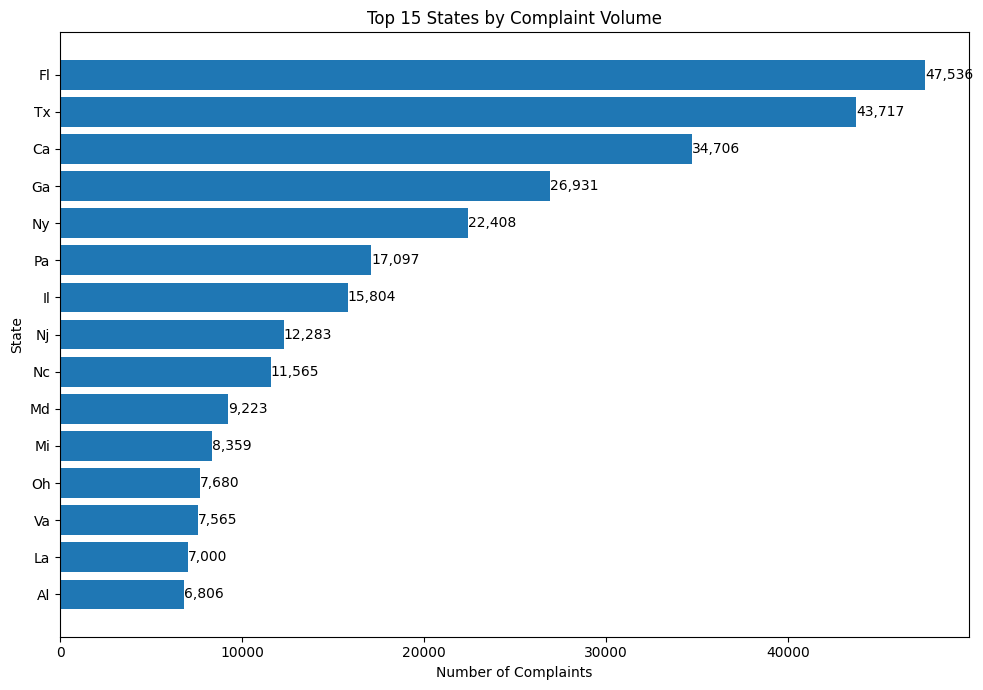

In [36]:
state_counts = (
    df["State"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10,7))

bars = plt.barh(
    state_counts.index,
    state_counts.values
)

plt.title("Top 15 States by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("State")

for bar in bars:

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "charts/chart_state_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 13 – Timely Response Analysis

Timely response is an important operational indicator for financial institutions.

This analysis compares complaint response timeliness using the values provided
in the CFPB dataset.

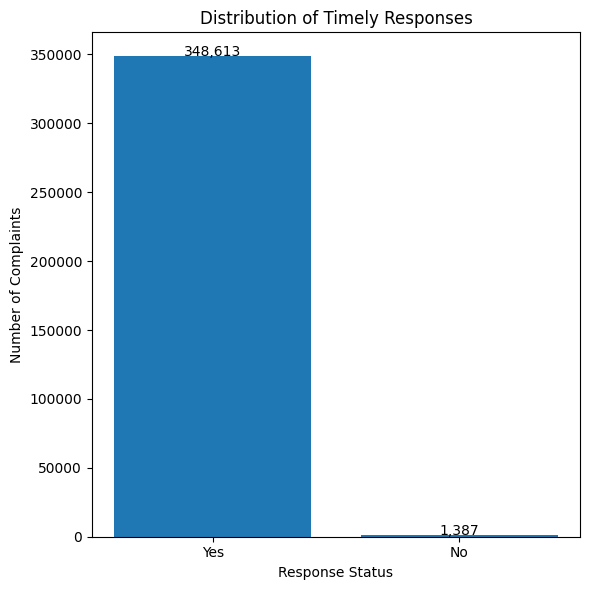

In [37]:
timely_counts = (
    df["Timely response?"]
    .value_counts()
)

plt.figure(figsize=(6,6))

bars = plt.bar(
    timely_counts.index,
    timely_counts.values
)

plt.title("Distribution of Timely Responses")
plt.xlabel("Response Status")
plt.ylabel("Number of Complaints")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
       "charts/chart_timely_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# EXPORT THE FINAL DATASET

In [38]:
output_file = "clean_compliance_data.csv"

df.to_csv(output_file, index=False)


print("DATASET EXPORTED")

print(f"Filename : {output_file}")
print(f"Rows     : {len(df):,}")
print(f"Columns  : {len(df.columns)}")

DATASET EXPORTED
Filename : clean_compliance_data.csv
Rows     : 350,000
Columns  : 22


# EXECUTTION INFORMATION


In [39]:
from datetime import datetime
import platform
import pandas as pd


print("EXECUTION INFORMATION")


print("Execution Time :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version :", platform.python_version())
print("Pandas Version :", pd.__version__)

EXECUTION INFORMATION
Execution Time : 2026-07-02 14:45:58
Python Version : 3.13.14
Pandas Version : 2.3.1


# Project Summary

The CFPB complaint dataset was successfully transformed into a clean,
analysis-ready dataset.

Major preprocessing tasks completed include:

- Duplicate removal
- Date standardization
- Missing value treatment
- Feature engineering
- Feature encoding
- Feature scaling

The processed dataset has been exported for future analytical or machine
learning tasks.

In [40]:

print("PROJECT COMPLETED SUCCESSFULLY")


print("Processed Dataset :", "clean_compliance_data.csv")
print("Charts Generated  :", 3)
print("Notebook Status   :", "Completed")

PROJECT COMPLETED SUCCESSFULLY
Processed Dataset : clean_compliance_data.csv
Charts Generated  : 3
Notebook Status   : Completed
